# Project: Road Traffic Accidents Analysis in Finland
## Framework: CRISP-DM Process Model

### 1. Business Understanding
In this phase, we explore the official spatial dataset of road traffic accidents provided by Statistics Finland (Tilastokeskus). Our objective is to determine if environmental and seasonal features (such as winter months) act as core triggers for highly severe road accidents, and to analyze this relationship using spatial visualization and Linear Regression modeling.

In [561]:
# TODO: tämä selitys vanhentunut ei käytetä lin. regressiota

### 2. Data Understanding
In this phase, we explore the official spatial dataset of road traffic accidents provided by Statistics Finland (Tilastokeskus). Our objective is to determine if environmental and seasonal features (such as winter months) act as core triggers for highly severe road accidents, and to analyze this relationship using spatial visualization and Linear Regression modeling.

In [562]:
# 1. Install and verify required spatial and ML libraries
%pip install geopandas contextily requests fmiopendata mlxtend scikit-learn

# 2. Import core engines
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import datetime as dt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from fmiopendata.wfs import download_stored_query
print("All core engines and machine learning libraries imported successfully!")

Note: you may need to restart the kernel to use updated packages.
All core engines and machine learning libraries imported successfully!



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Local Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [563]:
# 3. Data Loading - Correcting the separator to comma ',' as per actual data structure
csv_path = 'datasets/tieliikenne_2024.csv'
df_accidents = pd.read_csv(csv_path, sep=',')


In [564]:
print("Shape (rows, columns):", df_accidents.shape)
print("\nColumns:", list(df_accidents.columns))
print("\nData types:")
print(df_accidents.dtypes)

Shape (rows, columns): (2809, 17)

Columns: ['FID', 'id', 'geom', 'vvonn', 'kkonn', 'kello', 'vakav', 'onntyyppi', 'lkmhapa', 'lkmlaka', 'lkmjk', 'lkmpp', 'lkmmo', 'lkmmp', 'lkmmuukulk', 'x', 'y']

Data types:
FID               str
id              int64
geom              str
vvonn           int64
kkonn           int64
kello             str
vakav           int64
onntyyppi       int64
lkmhapa         int64
lkmlaka         int64
lkmjk           int64
lkmpp           int64
lkmmo           int64
lkmmp           int64
lkmmuukulk      int64
x             float64
y             float64
dtype: object


In total, there are 17 columns of data in the dataset. 

In [565]:
print("\nMissing values per column:")
print(df_accidents.isna().sum())


Missing values per column:
FID           0
id            0
geom          0
vvonn         0
kkonn         0
kello         1
vakav         0
onntyyppi     0
lkmhapa       0
lkmlaka       0
lkmjk         0
lkmpp         0
lkmmo         0
lkmmp         0
lkmmuukulk    0
x             0
y             0
dtype: int64


There is only one missing data for **kello**.

### 3. Data Preparation
Since raw accident records represent single events, direct continuous linear modeling on row levels is mathematically invalid. We perform an **Aggregation step** to compute total accidents grouped by month, establishing a true continuous numeric target variable suitable for Linear Regression modeling.

In [566]:
# Readable column names for presentation
readable_col_names =  {
"vvonn" : "vuosi",
"kkonn" : "kuukausi",
"kello" : "kello",
"vakav" : "vakavuus",
"onntyyppi" : "onnettomuustyyppi",
"lkmhapa" : "henkilö- ja pakettiautot",
"lkmlaka" : "linja- ja kuorma-autot",
"lkmjk" : "jalankulkijat",
"lkmpp" : "polkupyörät ja kevyet sähköajoneuvot",
"lkmmo" : "mopot",
"lkmmp" : "moottoripyörät",
"lkmmuukulk" : "muut kulkuneuvot",
"x" : "x",
"y" : "y"
}
#
df_accidents.rename( columns=readable_col_names, inplace=True)

### Converting class variables to 1-hot encoded columns

In [567]:
accident_types_raw = {
0 : "samat ajosuunnat (ajo suoraan)",
1 : "samat ajosuunnat (ajo kääntyen)",
2 : "vastakkaiset ajosuunnat (ajo suoraan)",
3 : "vastakkaiset ajosuunnat (ajo kääntyen)",
4 : "risteävät ajosuunnat (ajo suoraan)",
5 : "risteävät ajosuunnat (ajo kääntyen)",
6 : "jalankulkijaonnettomuus (suojatiellä)",
7 : "jalankulkijaonnettomuus (muualla)",
8 : "tieltä suistuminen",
9 : "muu onnettomuus"
}

accident_types_columns = {
0 : "type0",
1 : "type1",
2 : "type2",
3 : "type3",
4 : "type4",
5 : "type5",
6 : "type6",
7 : "type7",
8 : "type8",
9 : "type9"
}
# Create columns 'typeX' and assign boolean 1 or 0
for type_number, column_name in accident_types_raw.items():
    df_accidents[column_name] = [1 if accident_type == type_number else 0 for accident_type in df_accidents['onnettomuustyyppi']]

# Drop onnettomuustyyppi column
df_accidents.drop('onnettomuustyyppi', axis=1, inplace=True)

df_accidents.head(1)


,FID,id,geom,vuosi,kuukausi,kello,vakavuus,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,...,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus
0,tieliikenne_2024.1,1,POINT (423323.0412999997 6695927.4465),2024,7,00.00-00.59,2,1,0,0,...,0,0,0,1,0,0,0,0,0,0


In [568]:
# Convert accident lethality to 0 or 1
#df_accidents['vakavuus'] = [1 if vakavuus == 1 else 0 for vakavuus in df_accidents['vakavuus']]

df_accidents['vakavuus'] = df_accidents['vakavuus'].isin([1, 3]).astype(int)
df_accidents

,FID,id,geom,vuosi,kuukausi,kello,vakavuus,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,...,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus
0,tieliikenne_2024.1,1,POINT (423323.0412999997 6695927.4465),2024,7,00.00-00.59,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,tieliikenne_2024.2,2,POINT (306376.20660000015 6761653.649800001),2024,10,00.00-00.59,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2,tieliikenne_2024.3,3,POINT (259784.6640999997 6994822.009199999),2024,11,22.00-22.59,0,2,0,0,...,0,1,0,0,0,0,0,0,0,0
3,tieliikenne_2024.4,4,POINT (392858.12179999985 6681502.598200001),2024,1,15.00-15.59,0,1,1,0,...,1,0,0,0,0,0,0,0,0,0
4,tieliikenne_2024.5,5,POINT (383665.0440999996 6671405.377699999),2024,1,17.00-17.59,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2804,tieliikenne_2024.2805,2805,POINT (126484.77840000018 6682647.3047),2024,11,12.00-12.59,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2805,tieliikenne_2024.2806,2806,POINT (107800.28100000042 6683502.192500001),2024,12,17.00-17.59,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2806,tieliikenne_2024.2807,2807,POINT (116624.37719999999 6701750.947699999),2024,12,15.00-15.59,0,3,0,0,...,0,1,0,0,0,0,0,0,0,0
2807,tieliikenne_2024.2808,2808,POINT (110664.54220000003 6684589.5315000005),2024,12,08.00-08.59,0,2,0,0,...,1,0,0,0,0,0,0,0,0,0


### Converting cyclical time variable to linear difference from midday

The hours are are in String datatype and in format XX.00-XX.59.

We take the first two characters of each string in column 'kello' and convert that to float. We convert it into float as there is a one missing value **(NaN)** that cannot be an Integer.

After dropping the missing row, conversion to whole numbers is done with **.astype(int)**

In [569]:
df_accidents['tunti'] = df_accidents['kello'].str[:2].astype(float)

# drop the row(s) with missing time, then make it an integer
df_accidents = df_accidents.dropna(subset=['tunti'])
df_accidents['tunti'] = df_accidents['tunti'].astype(int)

# Subtracts each accident's hour from 12 and takes the absolute value
df_accidents['tunti'] = (12 - df_accidents['tunti']).abs()

# Drop the column 'kello'.
df_accidents = df_accidents.drop(columns=['kello'])

In [570]:
# Spatial Transformation - Convert to GeoDataFrame using Finnish coordinate system (EPSG:3067)
accidents_gdf = gpd.GeoDataFrame(
    df_accidents,
    geometry=gpd.points_from_xy(df_accidents.x, df_accidents.y),
    crs="EPSG:3067"
)

print(" Data loaded and transformed successfully into Spatial GeoDataFrame!")
display(accidents_gdf.head())

 Data loaded and transformed successfully into Spatial GeoDataFrame!


,FID,id,geom,vuosi,kuukausi,vakavuus,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,...,vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus,tunti,geometry
0,tieliikenne_2024.1,1,POINT (423323.0412999997 6695927.4465),2024,7,0,1,0,0,0,...,0,1,0,0,0,0,0,0,12,POINT (423323.041 6695927.446)
1,tieliikenne_2024.2,2,POINT (306376.20660000015 6761653.649800001),2024,10,0,1,0,0,0,...,0,0,0,0,0,0,1,0,12,POINT (306376.207 6761653.65)
2,tieliikenne_2024.3,3,POINT (259784.6640999997 6994822.009199999),2024,11,0,2,0,0,0,...,0,0,0,0,0,0,0,0,10,POINT (259784.664 6994822.009)
3,tieliikenne_2024.4,4,POINT (392858.12179999985 6681502.598200001),2024,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,3,POINT (392858.122 6681502.598)
4,tieliikenne_2024.5,5,POINT (383665.0440999996 6671405.377699999),2024,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,5,POINT (383665.044 6671405.378)


### More

In [571]:
# Drop id
df_accidents.drop('id', axis=1, inplace=True)

# Drop unnecessary string fields
df_accidents.drop('FID', axis=1, inplace=True)
df_accidents.drop('geom', axis=1, inplace=True)


# TODO: Delete this removal later, as of now 2024 holds no value
df_accidents.drop('vuosi', axis=1, inplace=True)
df_accidents.drop('kuukausi', axis=1, inplace=True)
df_accidents.drop('x', axis=1, inplace=True)
df_accidents.drop('y', axis=1, inplace=True)
df_accidents.drop('tunti', axis=1, inplace=True)


### 3.X Separating training and testing data

The data is divided into training (75%) and testing (25%). To guarantee same results across every run, a fixed **random_state** is applied.

In [572]:
from sklearn.model_selection import train_test_split

y = df_accidents['vakavuus']
X = df_accidents.drop(columns= 'vakavuus')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=69
)

In [573]:
# TODO: You can remove this later
X_train

,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus
2568,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
2786,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
503,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
163,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
1596,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2453,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
440,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1627,3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [574]:
# TODO: You can remove this later
X_test

,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus
48,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1131,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1157,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
976,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2312,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2682,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
572,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
680,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2016,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0


In [575]:
y_train

2568    0
2786    0
503     0
163     0
1596    0
       ..
278     0
2453    0
440     0
1627    0
2668    1
Name: vakavuus, Length: 2106, dtype: int64

In [576]:
y_test

48      0
1131    0
1157    0
976     0
2312    0
       ..
2682    0
572     0
680     0
2016    0
30      0
Name: vakavuus, Length: 702, dtype: int64

## 3.X Feature scaling

To prepare the features for moding, we standardize them using **Scikit-Learn's StandardScaler**. This transforms the features to have a mean of 0 and a standard deviation of 1.

The scaling is done due to Logistic Regression is sensitive to the scale of input features. Features with larger numeric ranges could otherwise dominate the model's coefficients.

Scaler is fitted strictly on the training set **X_train** to learn its mean and variance. These values are then applied to the test set **X_test**, ensuring no information from the testing data leaks into the training process.

In [577]:
## Scale features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on X_train data only to learn its mean and variance
X_train_scaled = scaler.fit_transform(X_train)
# Scale X_test using the exact same mean and variance learned from X_train
X_test_scaled = scaler.transform(X_test)

# Wrap results back into a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# assert the list sizes, small check.
assert len(X_train_scaled) == len(y_train) and len(X_test_scaled) == len(y_test)

print("Data Preparation Completed:")
print(f"Training set size: {X_train.shape[0]} samples.")
print(f"Testing set size: {X_test.shape[0]} samples.")

print("\n1. Without standardize features train data :")
display(X_train.head(5))

print("\n2. With standardize features train data (for the Logistic regression) :")
display(X_train_scaled.head(5))

Data Preparation Completed:
Training set size: 2106 samples.
Testing set size: 702 samples.

1. Without standardize features train data :


,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus
2568,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
2786,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
503,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
163,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
1596,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1



2. With standardize features train data (for the Logistic regression) :


,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus
0,-0.207252,-0.322995,-0.331279,-0.489239,-0.262649,3.408025,-0.241473,2.458349,-0.32034,-0.301043,-0.214941,-0.432606,-0.224442,-0.250126,-0.220918,-0.582833,-0.280880
1,-0.207252,-0.322995,-0.331279,-0.489239,-0.262649,-0.274530,-0.241473,-0.406777,-0.32034,-0.301043,-0.214941,-0.432606,-0.224442,-0.250126,-0.220918,-0.582833,3.560242
2,1.022249,-0.322995,-0.331279,-0.489239,-0.262649,-0.274530,-0.241473,2.458349,-0.32034,-0.301043,-0.214941,-0.432606,-0.224442,-0.250126,-0.220918,-0.582833,-0.280880
3,-1.436753,-0.322995,-0.331279,-0.489239,-0.262649,3.408025,-0.241473,-0.406777,-0.32034,-0.301043,-0.214941,-0.432606,-0.224442,-0.250126,-0.220918,-0.582833,3.560242
4,-1.436753,-0.322995,-0.331279,-0.489239,3.500196,-0.274530,-0.241473,-0.406777,-0.32034,-0.301043,-0.214941,-0.432606,-0.224442,-0.250126,-0.220918,-0.582833,3.560242


# TODO: ADD REGRESSION MODELING AND VALIDATION BELLOW

### 4. Modeling

With the data prepared, we initialize and train a **LogisticRegression** model from Scikit-Learn. The model is train using the **X_train_scaled** and **y_train**.


In [578]:
from sklearn.linear_model import LogisticRegression

# Model initialization and training
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [579]:
# TODO: Move to 5. Evaluation later

In [580]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Train accuracy
print("Train accuracy:", model.score(X_train_scaled, y_train))
# Test accuracy
print("Test accuracy: ", model.score(X_test_scaled, y_test))

Train accuracy: 0.8471035137701804
Test accuracy:  0.8447293447293447


              precision    recall  f1-score   support

           0       0.84      1.00      0.92       592
           1       1.00      0.01      0.02       110

    accuracy                           0.84       702
   macro avg       0.92      0.50      0.47       702
weighted avg       0.87      0.84      0.78       702



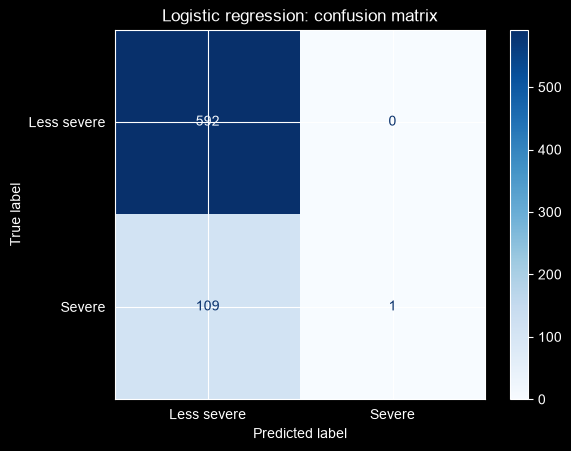

In [581]:
pred = model.predict(X_test_scaled)
print(classification_report(y_test, pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred,
    display_labels=['Less severe', 'Severe'],
    cmap='Blues'
)
plt.title('Logistic regression: confusion matrix')
plt.show()

In [583]:
print(y_train.value_counts())
print(y_test.value_counts())
print(df_accidents['vakavuus'].value_counts())

vakavuus
0    1786
1     320
Name: count, dtype: int64
vakavuus
0    592
1    110
Name: count, dtype: int64
vakavuus
0    2378
1     430
Name: count, dtype: int64


### 4. X Alternative Cross Validation
Cross validation instead of split validation

Accuracy: 0.85
Confusion Matrix:
 [[1781    5]
 [ 319    1]]


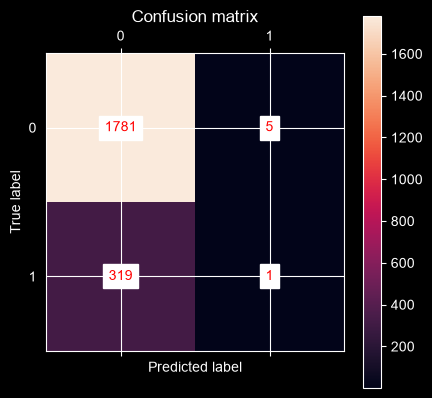

In [584]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

# cross-validation

y_pred = cross_val_predict(estimator=model, X=X_train_scaled, y=y_train, cv=10)

cm = confusion_matrix(y_train, y_pred)
accuracy = accuracy_score(y_train, y_pred)

print("Accuracy: %0.2f" % accuracy)
print("Confusion Matrix:\n", cm)

# visualize confusion matrix
plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
# include counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red', backgroundcolor='white')
plt.show()

### 4.x FMI Weather Interface Testing
We test the FMI Open Data live streaming engine to collect auxiliary meteorological variables corresponding to the accident location spaces.

In [585]:
# TODO: this is for testing weather data only

import pandas as pd
import datetime as dt
from fmiopendata.wfs import download_stored_query

try:
    print("Connecting to FMI Government server... Fetching raw spatial coordinates...")
    
    # 1. Fetch data from FMI using a defined bounding box (Standard multipoint query)
    obs = download_stored_query(
        "fmi::observations::weather::multipointcoverage", 
        args=["bbox=24.5,60.1,25.1,60.3"]
    )
    
    # 2. Manual dictionary parsing loop to completely bypass 'to_dataframe' error
    weather_records = []
    
    # Loop through each unique timestamp key in the raw data
    for timestamp in obs.data.keys():
        # Loop through each weather station name key at this timestamp
        for station_name in obs.data[timestamp].keys():
            station_data = obs.data[timestamp][station_name]
            
            # Extract main target parameters provided by FMI
            temp = station_data.get('Air temperature', {}).get('value', None)
            wind = station_data.get('Wind speed', {}).get('value', None)
            rh = station_data.get('Relative humidity', {}).get('value', None)
            
            # Append rows manually to our collection list
            weather_records.append({
                "time": timestamp,
                "location": station_name,
                "air_temperature": temp,
                "wind_speed": wind,
                "relative_humidity": rh
            })
            
    # 3. Construct the clean Pandas DataFrame manually!
    weather_df = pd.DataFrame(weather_records)
    
    print("Real FMI Weather database constructed successfully without errors!")
    print(f"Weather Data Shape: {weather_df.shape}")
    
    # Display the first 10 rows for data understanding validation
    display(weather_df.head(10))

except Exception as e:
    print(f"Final Engine Error Notice: {e}. Check server status.")


Connecting to FMI Government server... Fetching raw spatial coordinates...
Real FMI Weather database constructed successfully without errors!
Weather Data Shape: (1004, 5)


,time,location,air_temperature,wind_speed,relative_humidity
0,2026-10-08 02:20:00,Helsinki Kaisaniemi,4.9,0.6,98.0
1,2026-10-08 02:20:00,Helsinki Harmaja,9.5,0.7,76.0
2,2026-10-08 02:20:00,Helsinki Kumpula,4.1,0.7,99.0
3,2026-10-08 02:20:00,Espoo Nuuksio,2.6,1.6,100.0
4,2026-10-08 02:20:00,Espoo Tapiola,1.8,0.9,100.0
5,2026-10-08 02:30:00,Helsinki Kaisaniemi,4.9,0.5,98.0
6,2026-10-08 02:30:00,Helsinki Harmaja,9.4,0.7,77.0
7,2026-10-08 02:30:00,Helsinki Kumpula,4.1,0.9,99.0
8,2026-10-08 02:30:00,Espoo Nuuksio,3.1,1.3,100.0
9,2026-10-08 02:30:00,Espoo Tapiola,1.8,1.3,100.0


### 5. Evaluation

### 5.X Feature Importance

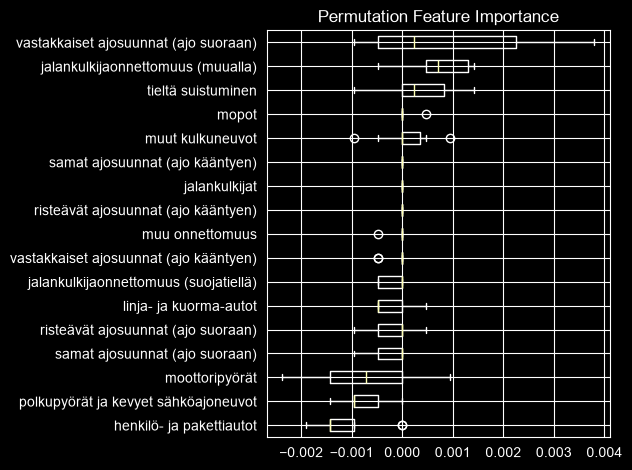

In [586]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance using the standardized model and scaled test data
result = permutation_importance(
    model,
    X_train_scaled,
    y_train,
    n_repeats=10, # TODO: what is good number of repeats?
    scoring="accuracy",
    random_state=69,
    n_jobs=-1
)

# Sort features by their mean importance score
sorted_idx = result.importances_mean.argsort()

# Plot the results
fig, ax = plt.subplots()
ax.boxplot(
    result.importances[sorted_idx].T,
    orientation="horizontal",
    tick_labels=X_train_scaled.columns[sorted_idx] #aikaisemmin df_accidents
)
ax.set_title("Permutation Feature Importance")
fig.tight_layout()
plt.show()


### 6. Deployment